In [1]:
# 환경설정
# .env 파일을 작업폴더에 업로드한뒤 api키가 출력되는지 확인합니다.
import os
from dotenv import load_dotenv
import json, re
from openai import OpenAI
import pandas as pd
import numpy as np
load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key=api_key)
print(api_key[:5])   # 키값 5개출력

sk-pr


# 1️⃣ [과제1: 필수] 프롬프트 6요소로 진료기록 다루기

LLM은 같은 데이터를 줘도 **어떻게 묻느냐에 따라 답이 완전히 달라집니다.**
STEP 0에서 쓴 프롬프트를 다시 보면, 그냥 물어본 게 아니라 역할·맥락·지시·제약·형식을 갖춰서 물어봤습니다. 이렇게 구조를 갖추면 원하는 형태로 안정적인 답이 나옵니다.
이번 단계에서는 **목적에 따라 프롬프트가 어떻게 달라지는지** 예시 세 개로 직접 확인합니다.
어제 배운 6요소가 실제로 어떻게 쓰이는지 보는 것입니다.

| 요소 | 뜻 | 예 |
| --- | --- | --- |
| 역할 | LLM에게 누구 행세를 시킬지 | "당신은 의료 데이터 분석가입니다" |
| 맥락 | 어떤 상황·자료인지 | "아래는 감기 환자 진료기록입니다" |
| 지시 | 무엇을 시킬지 | "각 환자를 한 문장으로 요약하세요" |
| 제약 | 지켜야 할 규칙 | "전문용어를 쓰지 마세요" |
| 형식 | 답의 모양 | "표로 답하세요" |
| 예시 | 원하는 답의 견본 | "예: 19세 남성, 5일간 두통 |

이 프롬프트는 "번호를 붙여 정확히 3개"라는 형식 지시로 답의 모양과 개수를 통제합니다. 즉 형식을 분명히 지정하면 LLM이 자유롭게 늘어놓지 않고 내가 원하는 틀에 맞춰 답한다는 것을 보여줍니다.

In [4]:
def summarize(prompt):
    res = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
    )
    return res.choices[0].message.content


# 데이터 불러오기
with open("진료기록_30.json", encoding="utf-8") as f:
    records = json.load(f)

prompt = f"""역할: 당신은 의료 데이터 분석가입니다.
맥락: 아래는 감기 환자의 진료기록입니다.
지시: 이 데이터로 해볼 수 있는 분석 주제를 제안하세요.
제약: 데이터에 실제로 있는 항목만 근거로 삼으세요.
형식: 번호를 붙여 정확히 3개만 제안하세요.

데이터:
{records }
"""

print(summarize(prompt))

1. **성별에 따른 감기 진단 분석**: 데이터 내 성별(남성, 여성)에 따른 급성 비인두염, 급성 기관지염, 독감 의심 등의 진단 비율을 분석하여, 어떤 성별이 더 많이 특정 감기 질환에 걸리는지를 조사합니다. 이를 통해 성별에 따른 감기 질환의 취약성을 파악할 수 있습니다.

2. **연령대별 증상 및 진단 분포 분석**: 환자 데이터를 연령대별로 구분하여 각 연령대의 주요 증상(두통, 인후통, 피로감 등)과 진단(급성 비인두염, 급성 기관지염 등)의 관계를 분석합니다. 이를 통해 특정 연령대에서 흔히 나타나는 감기 증상 및 질환을 파악할 수 있습니다.

3. **체온에 따른 진단 분석**: 환자의 체온과 진단 결과를 분석하여, 특정 체온 범위에서 어떤 진단이 주로 내려지는지를 조사합니다. 예를 들어, 37도 이하에서 주로 진단되는 질병과 38도 이상의 발열이 있는 환자의 진단 차이를 비교할 수 있습니다. 이를 통해 진단의 신뢰성을 높이고 적절한 치료법을 제안할 수 있는 기초 데이터를 마련할 수 있습니다.


**📌 변형 과제**
형식을 "정확히 3개" 에서 "정확히 5개, 각 주제마다 한 줄 설명을 덧붙여서" 로 바꿔 실행하세요.
형식 지시를 바꿨더니 답의 모양이 그대로 따라오나요? LLM이 5개를 정확히 지키나요?

In [3]:
# 데이터 불러오기
with open("진료기록_30.json", encoding="utf-8") as f:
    records = json.load(f)

prompt = f"""역할: 당신은 의료 데이터 분석가입니다.
맥락: 아래는 감기 환자의 진료기록입니다.
지시: 이 데이터로 해볼 수 있는 분석 주제를 제안하세요.
제약: 데이터에 실제로 있는 항목만 근거로 삼으세요.
형식: 번호를 붙여 정확히 5개, 각 주제마다 한 줄 설명을 덧붙여서

데이터:
{records }
"""

print(summarize(prompt))

NameError: name 'summarize' is not defined

이 프롬프트는 LLM에게 "의료 코디네이터" 역할을 맡기고, "어려운 용어 금지·부드러운 말투"라는 제약을 걸어 환자 눈높이의 요약을 끌어냅니다. 즉 같은 진료기록이라도 역할과 제약을 어떻게 주느냐에 따라 누구를 위한 요약인지가 결정될수 있다는걸 실습합니다.

In [15]:
# 환자 한 명만 뽑기
data= records[0]          # 첫 번째 환자 (P001)
print(data)                # 어떤 환자인지 확인


# 이 환자 한 명을 넣은 프롬프트
prompt = f"""역할: 당신은 환자에게 진료 내용을 쉽게 설명하는 의료 코디네이터입니다.
맥락: 아래는 환자 한 명의 진료기록입니다.
지시: 이 환자의 상태를 한 문장으로 요약하세요.
제약: 어려운 의학용어를 쓰지 말고, 환자가 안심할 수 있는 부드러운 말투로 쓰세요.

데이터:
{data}
"""

print(summarize(prompt))

{'patient_id': 'P001', 'visit_date': '2025-07-02', 'age': 19, 'sex': 'M', 'symptoms': ['두통', '인후통', '재채기'], 'temperature': 36.7, 'symptom_days': 5, 'diagnosis': '급성 비인두염', 'prescription': '수액 처방', 'visit_type': '초진', 'note': '19세 남성 환자로 5일 전부터 두통, 인후통, 재채기 증상 호소. 체온 36.7도로 미열은 없음. 급성 비인두염 진단 하에 수액 처방 처방함.'}
환자는 5일간 두통과 인후통, 재채기를 겪고 있으며, 급성 비인두염 진단을 받아 수액 치료를 받고 있습니다.


**📌  변형과제**
역할을 "환자에게 설명하는 의료 코디네이터" 대신 "보험 심사 담당자" 로 바꾸고, 어울리게 제약도 고쳐서 다시 실행하세요. 같은 환자인데 요약의 말투와 강조점이 어떻게 달라지나요?

In [16]:
# 환자 한 명만 뽑기
data= records[0]          # 첫 번째 환자 (P001)
print(data)                # 어떤 환자인지 확인


# 이 환자 한 명을 넣은 프롬프트
prompt = f"""역할: 당신은 환자의 보험 심사 담당자입니다.
맥락: 아래는 환자 한 명의 진료기록입니다.
지시: 이 환자의 상태를 한 문장으로 요약하세요.
제약: 보험심사 담당자로서 환자에게 도움이 될만한 정보를 같이 제공하세요.

데이터:
{data}
"""

print(summarize(prompt))

{'patient_id': 'P001', 'visit_date': '2025-07-02', 'age': 19, 'sex': 'M', 'symptoms': ['두통', '인후통', '재채기'], 'temperature': 36.7, 'symptom_days': 5, 'diagnosis': '급성 비인두염', 'prescription': '수액 처방', 'visit_type': '초진', 'note': '19세 남성 환자로 5일 전부터 두통, 인후통, 재채기 증상 호소. 체온 36.7도로 미열은 없음. 급성 비인두염 진단 하에 수액 처방 처방함.'}
19세 남성 환자는 급성 비인두염 진단을 받았으며, 두통, 인후통, 재채기 증상을 5일 간 호소하고 있습니다. 

보험 심사 담당자로서, 환자에게는 급성 비인두염 치료에 따른 보험 적용 여부와 수액 처방에 대한 비용 청구 방식에 대해 확인하는 것이 중요합니다. 필요한 경우 전문의의 추가 진료를 받도록 권장합니다.


이 프롬프트는 원하는 출력 모양을 예시 한 줄로 직접 보여줘서 LLM이 그 형태를 그대로 따라 하게 만듭니다. 즉 말로 길게 설명하는 것보다 견본을 하나 보여주는 편이 형식을 더 정확히 맞춘다는 것을 보여주며, 이렇게 예시를 주는 방식을 Few-shot이라고 합니다.

In [19]:
# 환자 한 명만 뽑기
data= records[0]          # 첫 번째 환자 (P001)
print(data)                # 어떤 환자인지 확인

prompt = f"""역할: 당신은 진료기록에서 핵심 정보를 추출하는 도구입니다.
맥락: 아래는 환자의 진료기록입니다.
지시:  환자의 '나이 / 주요 증상 / 진단'만 뽑아 한 줄로 출력하세요.
형식: 아래 예시와 똑같은 모양으로 출력하세요.
예시: 19세 / 두통·인후통 / 급성 비인두염

데이터:
{data}
"""

print(data)
print(summarize(prompt))

{'patient_id': 'P001', 'visit_date': '2025-07-02', 'age': 19, 'sex': 'M', 'symptoms': ['두통', '인후통', '재채기'], 'temperature': 36.7, 'symptom_days': 5, 'diagnosis': '급성 비인두염', 'prescription': '수액 처방', 'visit_type': '초진', 'note': '19세 남성 환자로 5일 전부터 두통, 인후통, 재채기 증상 호소. 체온 36.7도로 미열은 없음. 급성 비인두염 진단 하에 수액 처방 처방함.'}
{'patient_id': 'P001', 'visit_date': '2025-07-02', 'age': 19, 'sex': 'M', 'symptoms': ['두통', '인후통', '재채기'], 'temperature': 36.7, 'symptom_days': 5, 'diagnosis': '급성 비인두염', 'prescription': '수액 처방', 'visit_type': '초진', 'note': '19세 남성 환자로 5일 전부터 두통, 인후통, 재채기 증상 호소. 체온 36.7도로 미열은 없음. 급성 비인두염 진단 하에 수액 처방 처방함.'}
19세 / 두통·인후통·재채기 / 급성 비인두염


**📌 변형 과제**
예시 줄을 통째로 지우고 실행해 보세요. 그다음 다시 넣고 실행하세요. 예시가 있을 때와 없을 때, 출력 모양이 얼마나 달라지나요? (예시를 주는 방식을 Few-shot이라고 합니다.)

In [20]:
# 환자 한 명만 뽑기
data= records[0]          # 첫 번째 환자 (P001)
print(data)                # 어떤 환자인지 확인

prompt = f"""역할: 당신은 진료기록에서 핵심 정보를 추출하는 도구입니다.
맥락: 아래는 환자의 진료기록입니다.
지시:  환자의 '나이 / 주요 증상 / 진단'만 뽑아 한 줄로 출력하세요.


데이터:
{data}
"""

print(data)
print(summarize(prompt))

{'patient_id': 'P001', 'visit_date': '2025-07-02', 'age': 19, 'sex': 'M', 'symptoms': ['두통', '인후통', '재채기'], 'temperature': 36.7, 'symptom_days': 5, 'diagnosis': '급성 비인두염', 'prescription': '수액 처방', 'visit_type': '초진', 'note': '19세 남성 환자로 5일 전부터 두통, 인후통, 재채기 증상 호소. 체온 36.7도로 미열은 없음. 급성 비인두염 진단 하에 수액 처방 처방함.'}
{'patient_id': 'P001', 'visit_date': '2025-07-02', 'age': 19, 'sex': 'M', 'symptoms': ['두통', '인후통', '재채기'], 'temperature': 36.7, 'symptom_days': 5, 'diagnosis': '급성 비인두염', 'prescription': '수액 처방', 'visit_type': '초진', 'note': '19세 남성 환자로 5일 전부터 두통, 인후통, 재채기 증상 호소. 체온 36.7도로 미열은 없음. 급성 비인두염 진단 하에 수액 처방 처방함.'}
19세 / 두통, 인후통, 재채기 / 급성 비인두염


지금까지는 정해진 프롬프트를 따라 실행했습니다.
이번엔 **여러분이 직접** 하고 싶은 작업을 정하고, 그에 맞는 프롬프트를 6요소로 설계해 보세요.

예를 들어 이런 것들이 가능합니다(아래는 예시일 뿐, 무엇이든 좋습니다).

- 진료기록을 보고 환자에게 보낼 **주의사항 안내문** 만들기
- 진료기록을 **영어로** 요약하기
- 의사용 **차트 메모** 형태로 짧게 정리하기

**할 일**

1. 어떤 작업을 시킬지 한 줄로 정합니다. (= 내가 의도한 것)
2. 그 작업에 맞게 6요소(역할·맥락·지시·제약·형식·예시)를 채워 프롬프트를 만듭니다.
3. 실행하고 결과를 확인합니다. 원하는 대로 안 나오면 프롬프트를 고쳐서 다시 시도합니다.

In [21]:
# 환자 한 명만 뽑기
data= records[0]          # 첫 번째 환자 (P001)
print(data)                # 어떤 환자인지 확인

prompt = f"""당신은 외래 진료 기록 작성을 보조하는 의료 차팅 어시스턴트입니다.

목표는 의사가 입력한 구조화된 환자 진료 데이터를 바탕으로, 전자의무기록(EMR)에 입력하기 좋은 한국어 차팅 문장을 작성하는 것입니다.

다음 원칙을 반드시 지키세요.

1. 입력 데이터에 존재하는 사실만 사용하세요.
2. 입력에 없는 증상, 검사 결과, 과거력, 약물, 알레르기, 진찰 소견은 임의로 추가하지 마세요.
3. 진단명과 처방은 입력값을 그대로 기반으로 정리하되, 새로운 진단이나 치료를 제안하지 마세요.
4. 의학적 판단은 최종적으로 의사가 한다는 전제에서, 차팅 보조 문서만 작성하세요.
5. 문장은 의무기록에 적합하게 간결하고 객관적으로 작성하세요.
6. 정보가 부족하거나 확인이 필요한 부분은 “확인 필요” 항목에 따로 표시하세요.

출력 형식은 다음과 같이 작성하세요.

[기본 정보]

* 환자 ID:
* 내원일:
* 성별/나이:
* 내원 유형:

[SOAP 차팅 초안]
S - Subjective:
환자가 호소한 증상과 증상 지속 기간을 정리하세요.

O - Objective:
입력 데이터에 있는 객관적 정보만 정리하세요. 예: 체온

A - Assessment:
입력 데이터에 있는 진단명을 바탕으로 정리하세요.

P - Plan:
입력 데이터에 있는 처방 내용을 바탕으로 정리하세요.

[EMR용 자연어 차팅]
의사가 바로 참고할 수 있도록 한 문단으로 자연스럽게 작성하세요.

[확인 필요]
입력 데이터만으로 부족하거나, 의사가 추가 확인하면 좋을 항목을 적으세요. 단, 새로운 의학적 판단을 단정하지 마세요.


입력 데이터:
{data}
"""

print(summarize(prompt))

{'patient_id': 'P001', 'visit_date': '2025-07-02', 'age': 19, 'sex': 'M', 'symptoms': ['두통', '인후통', '재채기'], 'temperature': 36.7, 'symptom_days': 5, 'diagnosis': '급성 비인두염', 'prescription': '수액 처방', 'visit_type': '초진', 'note': '19세 남성 환자로 5일 전부터 두통, 인후통, 재채기 증상 호소. 체온 36.7도로 미열은 없음. 급성 비인두염 진단 하에 수액 처방 처방함.'}
[기본 정보]

* 환자 ID: P001
* 내원일: 2025-07-02
* 성별/나이: 남성/19세
* 내원 유형: 초진

[SOAP 차팅 초안]
S - Subjective:
환자는 5일 전부터 두통, 인후통, 재채기를 호소하고 있습니다.

O - Objective:
체온은 36.7도이며, 미열은 없습니다.

A - Assessment:
급성 비인두염으로 진단합니다.

P - Plan:
수액 처방을 진행하였습니다.

[EMR용 자연어 차팅]
19세 남성 환자가 2025년 7월 2일 초진으로 내원하였습니다. 환자는 5일 전부터 두통, 인후통, 재채기 증상을 호소하였으며, 체온은 36.7도로 미열은 없습니다. 급성 비인두염으로 진단하고 수액 처방을 진행하였습니다.

[확인 필요]
추가적인 진찰 소견이나 검사 결과가 필요한지 확인이 필요합니다.


In [22]:
import gradio as gr
import json

def summarize(prompt):
    res = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
    )
    return res.choices[0].message.content


# 환자ID를 넣으면 요약해주는 함수
def run(patient_id):
    # 고른 환자 한 명 뽑기
    data = None
    for r in records:
        if r["patient_id"] == patient_id:
            data = r

    # 이 환자 한 명을 넣은 프롬프트
    prompt = f"""역할: 당신은 환자에게 진료 내용을 쉽게 설명하는 의료 코디네이터입니다.
맥락: 아래는 환자 한 명의 진료기록입니다.
지시: 이 환자의 상태를 한 문장으로 요약하세요.
제약: 어려운 의학용어를 쓰지 말고, 환자가 안심할 수 있는 부드러운 말투로 쓰세요.

데이터:
{data}
"""
    return summarize(prompt)


# 화면 만들기
demo = gr.Interface(
    fn=run,
    inputs=gr.Dropdown([r["patient_id"] for r in records], label="환자 선택"),
    outputs=gr.Textbox(label="요약"),
    title="진료기록 요약",
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.


In [29]:
demo.close()

Closing server running on port: 7864


In [8]:
import gradio as gr
import json
import os
from dotenv import load_dotenv, find_dotenv
from openai import OpenAI

# =========================
# 1. 환경 설정
# =========================

# .env가 프로젝트 루트에 있고 이름이 정확히 .env인 경우
load_dotenv(find_dotenv(usecwd=True))

client = OpenAI()

# =========================
# 2. 데이터 로드
# =========================

# 노트북 위치 기준으로 경로 조정 필요
# 예: 현재 노트북이 하위폴더라면 "../진료기록_30.json"

record_map = {r["patient_id"]: r for r in records}


# =========================
# 3. 시스템 프롬프트
# =========================

SYSTEM_PROMPT = """
당신은 의사의 외래 진료 기록 작성을 보조하는 의료 차팅 어시스턴트입니다.

역할:
- 환자 진료 데이터를 바탕으로 차팅, 요약, SOAP 정리, 환자 설명문 작성을 돕습니다.
- 의사의 최종 판단을 보조할 뿐, 진단이나 처방을 새로 결정하지 않습니다.

원칙:
1. 입력된 환자 데이터에 있는 사실만 사용하세요.
2. 입력에 없는 증상, 검사 결과, 과거력, 알레르기, 진찰 소견, 약물 정보는 임의로 만들지 마세요.
3. 진단명과 처방은 입력 데이터에 있는 내용만 기반으로 정리하세요.
4. 의학적 판단이 필요한 부분은 단정하지 말고 “확인 필요”로 표시하세요.
5. 답변은 의사가 빠르게 확인할 수 있도록 간결하고 구조화하세요.
6. 환자에게 설명하는 문장을 요청받으면 쉬운 표현으로 바꾸되, 새로운 의학 정보를 추가하지 마세요.
"""


# =========================
# 4. 함수 정의
# =========================

def get_patient(patient_id):
    return record_map.get(patient_id)


def show_patient_info(patient_id):
    """
    환자를 선택하면 왼쪽에 환자 JSON 표시.
    환자를 바꾸면 대화창도 초기화.
    """
    patient_data = get_patient(patient_id)

    if patient_data is None:
        return "환자 정보를 찾지 못했습니다.", []

    patient_json = json.dumps(patient_data, ensure_ascii=False, indent=2)
    return patient_json, []

def build_messages(patient_data, user_message, history):
    """
    OpenAI API에 넣을 messages 구성.
    현재 Gradio Chatbot history는 messages 형식:
    [{"role": "user", "content": "..."}, {"role": "assistant", "content": "..."}]
    """
    history = history or []

    messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT
        },
        {
            "role": "user",
            "content": f"""
다음은 현재 선택된 환자의 진료 데이터입니다.
반드시 이 데이터에 근거해서만 답변하세요.

환자 데이터:
{json.dumps(patient_data, ensure_ascii=False, indent=2)}
"""
        }
    ]

    # 이전 대화 추가
    for msg in history:
        if isinstance(msg, dict):
            role = msg.get("role")
            content = msg.get("content")

            if role in ["user", "assistant"] and content:
                messages.append({
                    "role": role,
                    "content": content
                })

    # 현재 질문 추가
    messages.append({
        "role": "user",
        "content": user_message
    })

    return messages


def ask_llm(patient_data, user_message, history):
    messages = build_messages(patient_data, user_message, history)

    res = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=messages,
        temperature=0.2,
    )

    return res.choices[0].message.content

def chat(patient_id, user_message, history):
    """
    질문하기 버튼 또는 엔터 입력 시 실행.
    현재 Gradio Chatbot 형식:
    [{"role": "user", "content": 질문}, {"role": "assistant", "content": 답변}]
    """
    history = history or []

    if not patient_id:
        history.append({
            "role": "assistant",
            "content": "먼저 환자를 선택해주세요."
        })
        return "", history

    if not user_message or not user_message.strip():
        history.append({
            "role": "assistant",
            "content": "질문을 입력해주세요."
        })
        return "", history

    patient_data = get_patient(patient_id)

    if patient_data is None:
        history.append({
            "role": "assistant",
            "content": "선택한 환자의 진료기록을 찾지 못했습니다."
        })
        return "", history

    try:
        answer = ask_llm(patient_data, user_message, history)
    except Exception as e:
        answer = f"오류가 발생했습니다: {e}"

    history.append({
        "role": "user",
        "content": user_message
    })
    history.append({
        "role": "assistant",
        "content": answer
    })

    return "", history


def clear_chat():
    return []


# =========================
# 5. Gradio UI
# =========================

with gr.Blocks() as demo:
    gr.Markdown("# 의사용 진료 보조 챗봇")
    gr.Markdown(
        "환자를 선택한 뒤, 진료기록을 기반으로 SOAP, EMR 차팅, 환자 설명문, 확인 필요 항목을 생성합니다."
    )

    with gr.Row():
        with gr.Column(scale=1):
            patient_dropdown = gr.Dropdown(
                choices=[r["patient_id"] for r in records],
                value=records[0]["patient_id"] if records else None,
                label="환자 선택"
            )

            patient_info = gr.Textbox(
                label="선택된 환자 데이터",
                lines=18,
                interactive=False
            )

        with gr.Column(scale=2):
            chatbot = gr.Chatbot(
                label="진료 보조 챗봇"
            )

            msg = gr.Textbox(
                label="의사 질문",
                placeholder="예: 이 환자를 SOAP 형식으로 정리해줘.",
                lines=3
            )

            with gr.Row():
                send_btn = gr.Button("질문하기")
                clear_btn = gr.Button("대화 초기화")

            gr.Markdown("### 빠른 요청")

            with gr.Row():
                soap_btn = gr.Button("SOAP 생성")
                emr_btn = gr.Button("EMR 차팅")
                patient_btn = gr.Button("환자 설명문")
                check_btn = gr.Button("확인 필요")

            with gr.Row():
                summary_btn = gr.Button("한 줄 요약")
                table_btn = gr.Button("핵심 정보 표")
                rewrite_btn = gr.Button("차팅 문장 다듬기")


    # =========================
    # 6. 이벤트 연결
    # =========================

    # 앱 시작 시 첫 환자 정보 표시
    demo.load(
        fn=show_patient_info,
        inputs=patient_dropdown,
        outputs=[patient_info, chatbot]
    )

    # 환자 변경 시 환자 정보 갱신 + 대화 초기화
    patient_dropdown.change(
        fn=show_patient_info,
        inputs=patient_dropdown,
        outputs=[patient_info, chatbot]
    )

    # 질문하기 버튼
    send_btn.click(
        fn=chat,
        inputs=[patient_dropdown, msg, chatbot],
        outputs=[msg, chatbot]
    )

    # 엔터 입력
    msg.submit(
        fn=chat,
        inputs=[patient_dropdown, msg, chatbot],
        outputs=[msg, chatbot]
    )

    # 대화 초기화
    clear_btn.click(
        fn=clear_chat,
        inputs=None,
        outputs=chatbot
    )

    # 빠른 요청 버튼들: 버튼 클릭 시 질문창에 문구만 입력
    soap_btn.click(
        fn=lambda: "이 환자의 진료기록을 SOAP 형식으로 정리해줘.",
        inputs=None,
        outputs=msg
    )

    emr_btn.click(
        fn=lambda: "이 환자의 내용을 EMR에 넣기 좋은 자연어 차팅 문장으로 작성해줘.",
        inputs=None,
        outputs=msg
    )

    patient_btn.click(
        fn=lambda: "이 환자에게 쉽게 설명할 수 있는 문장으로 바꿔줘.",
        inputs=None,
        outputs=msg
    )

    check_btn.click(
        fn=lambda: "이 진료기록에서 의사가 추가로 확인하면 좋을 항목을 정리해줘.",
        inputs=None,
        outputs=msg
    )

    summary_btn.click(
        fn=lambda: "이 환자의 상태를 의사용으로 한 문장 요약해줘.",
        inputs=None,
        outputs=msg
    )

    table_btn.click(
        fn=lambda: "이 환자의 핵심 정보를 표 형태로 정리해줘. 증상, 체온, 증상 기간, 진단, 처방을 포함해줘.",
        inputs=None,
        outputs=msg
    )

    rewrite_btn.click(
        fn=lambda: "이 환자의 note를 EMR에 적합한 객관적 차팅 문장으로 다듬어줘.",
        inputs=None,
        outputs=msg
    )


demo.launch()

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.



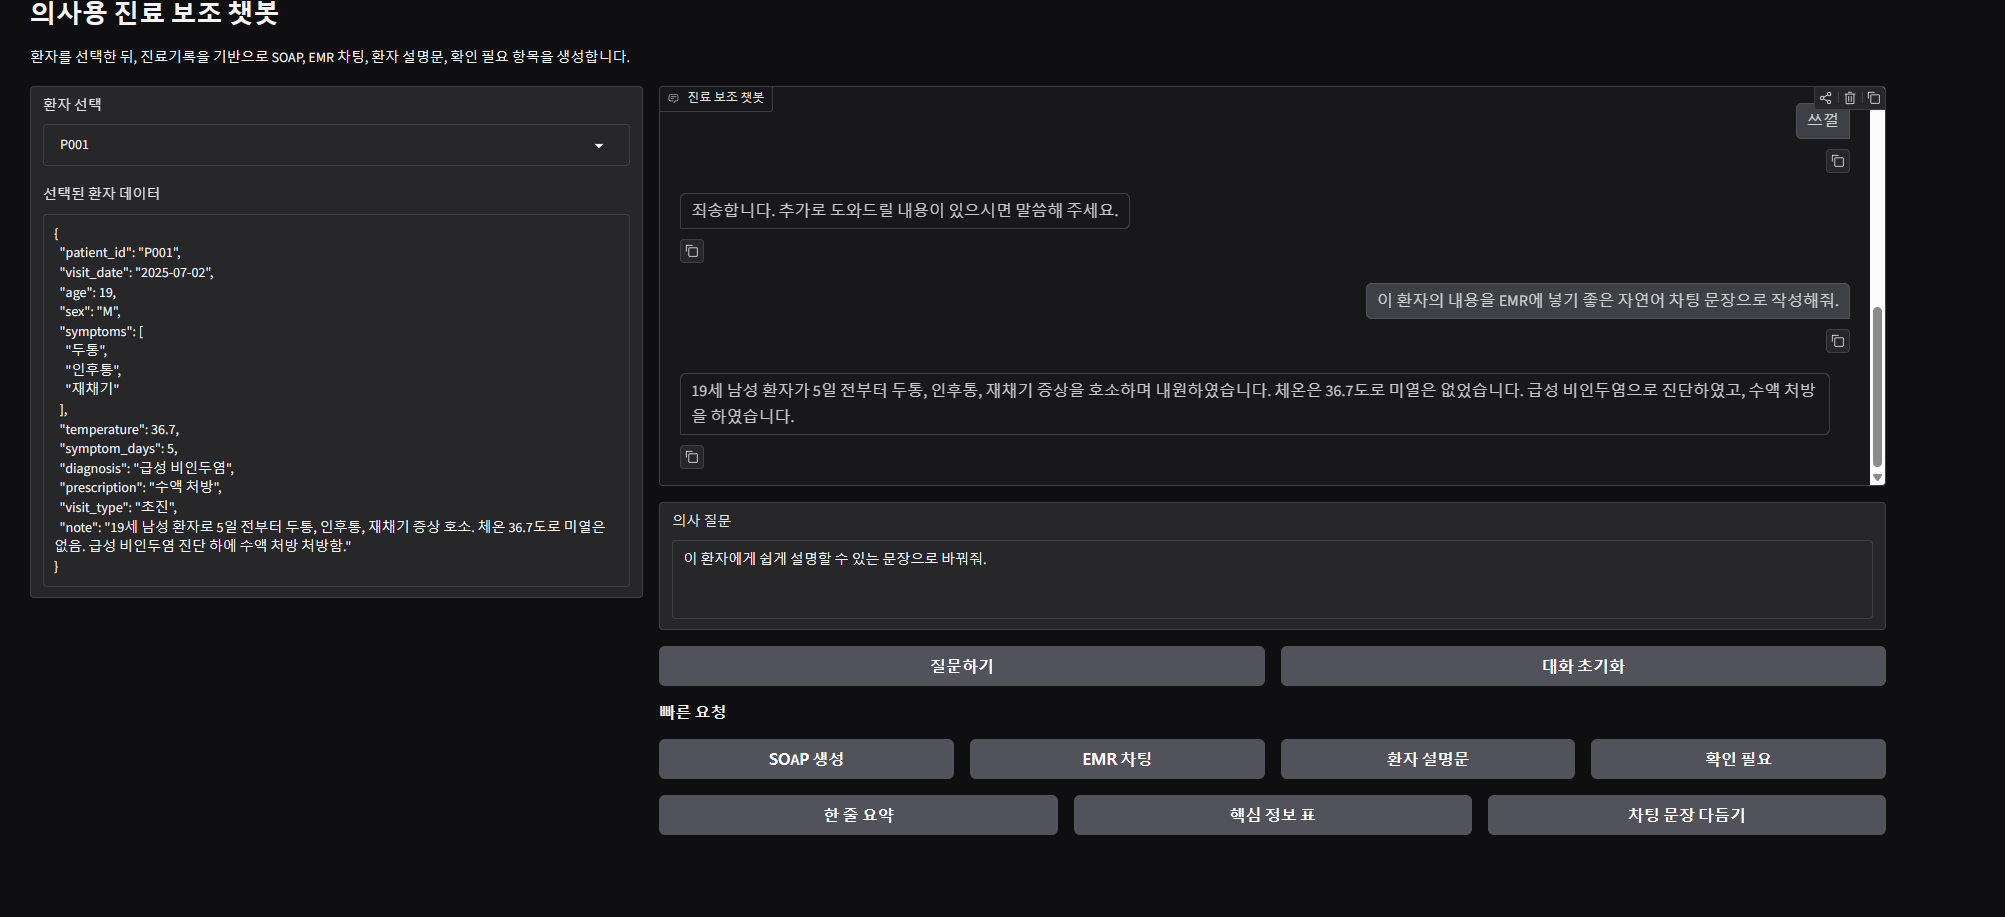

In [7]:
demo.close()

Closing server running on port: 7863


In [9]:
import json
import numpy as np

# 데이터 불러오기

# 1) 임베딩에 넣을 글자 만들기 (증상 + 진단)
def to_text(r):
    return f"증상: {r['symptoms']}, 진단: {r['diagnosis']}"

texts = [to_text(r) for r in records]
print("예시 입력:", texts[0])

# 2) 글자를 임베딩(숫자 벡터)으로 바꾸기
res = client.embeddings.create(
    model="text-embedding-3-small",
    input=texts,
)
vectors = [d.embedding for d in res.data]   # 30개의 벡터
print("벡터 개수:", len(vectors), "/ 벡터 길이:", len(vectors[0]))

# 3) 두 벡터가 얼마나 비슷한지 재는 함수 (코사인 유사도)
def cosine(a, b):
    a, b = np.array(a), np.array(b)
    return a @ b / (np.linalg.norm(a) * np.linalg.norm(b))

# 4) 0번 환자와 가장 비슷한 환자 찾기
target = 0
sims = [cosine(vectors[target], vectors[i]) for i in range(len(vectors))]
order = np.argsort(sims)[::-1]   # 비슷한 순으로 정렬

print(f"\n[기준] {records[target]['patient_id']} - {records[target]['diagnosis']}")
print("가장 비슷한 환자 3명:")
for i in order[1:4]:             # 자기 자신(0번) 빼고 상위 3명
    print(f"  {records[i]['patient_id']} - {records[i]['diagnosis']} (유사도 {sims[i]:.3f})")

예시 입력: 증상: ['두통', '인후통', '재채기'], 진단: 급성 비인두염
벡터 개수: 30 / 벡터 길이: 1536

[기준] P001 - 급성 비인두염
가장 비슷한 환자 3명:
  P017 - 급성 비인두염 (유사도 0.889)
  P029 - 급성 인두염 (유사도 0.832)
  P010 - 급성 인두염 (유사도 0.817)
